# Key Detection from Audio

This notebook estimates the musical key of an audio file by:

1. loading an audio file,
2. converting it into a chromagram,
3. averaging pitch-class energy across the clip,
4. comparing that pitch profile against major/minor key templates, and
5. reporting the most likely key with a simple confidence estimate.

## 1. Setup

Install and import the libraries used for audio analysis, math, plotting, and file checks.

In [1]:
# Install librosa if needed. In Google Colab, this is usually safe to run.
!pip install librosa

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

print("librosa version:", librosa.__version__)

librosa version: 0.11.0


## 2. Choose the audio file

This version assumes the audio file lives in Google Drive. Update `audio_filename` if you want to analyze a different file.

In [19]:
from google.colab import drive

drive.mount('/content/drive')

# Change this path to whichever audio file you want to analyze.
# audio_filename = '/content/drive/MyDrive/Capstone/Audio/G, D, F, C.m4a'
audio_filename = '/content/drive/MyDrive/Capstone/GuitarSet/Audio/00_Funk1-97-C_comp_mic.wav'

if os.path.exists(audio_filename):
    print(f"Found: {audio_filename}")
else:
    raise FileNotFoundError(
        f"Could not find the audio file at: {audio_filename}\n"
        "Check the path or upload/move the file into Google Drive."
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found: /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_Funk1-97-C_comp_mic.wav


## 3. Load the audio and compute the chromagram

A chromagram summarizes the audio into 12 pitch classes: C, C#, D, D#, E, F, F#, G, G#, A, A#, and B.

In [20]:
# Load audio. y is the waveform; sr is the sample rate.
y, sr = librosa.load(audio_filename, sr=None)
print(f"Loaded {len(y) / sr:.1f} seconds of audio at {sr} Hz")

# Compute chromagram: energy for each of the 12 pitch classes over time.
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
print(f"Chromagram shape: {chroma.shape}")
print(f"  (12 pitch classes, {chroma.shape[1]} time frames)")

Loaded 29.7 seconds of audio at 44100 Hz
Chromagram shape: (12, 2558)
  (12 pitch classes, 2558 time frames)


## 4. Visualize pitch energy over time

Brighter regions mean that pitch class is more prominent at that moment in the audio.

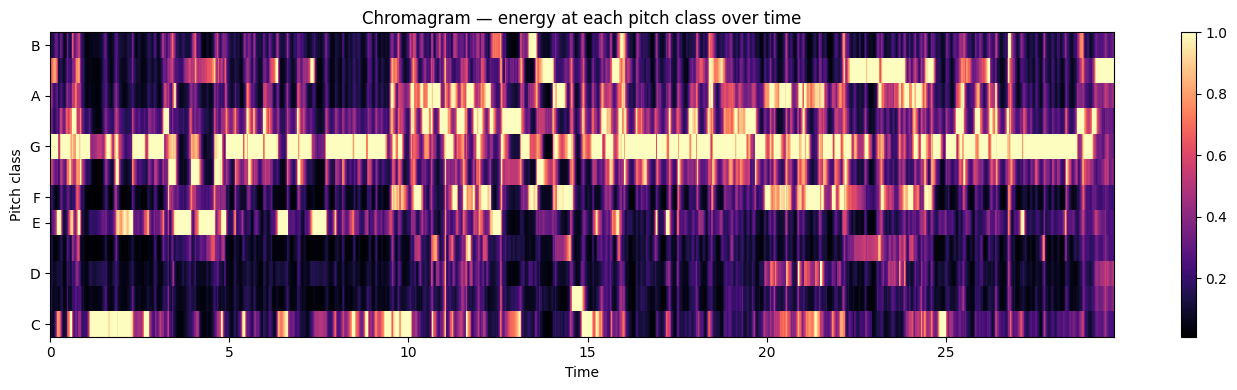

In [21]:
fig, ax = plt.subplots(figsize=(14, 4))
img = librosa.display.specshow(
    chroma,
    y_axis='chroma',
    x_axis='time',
    sr=sr,
    cmap='magma',
    ax=ax
)
plt.colorbar(img, ax=ax)
ax.set_title('Chromagram — energy at each pitch class over time')
plt.tight_layout()
plt.show()

## 5. Average the chromagram into one pitch profile

This collapses the whole clip into one 12-number summary showing which notes were strongest overall.

In [22]:
# Average chromagram across time → single 12-element vector.
chroma_avg = np.mean(chroma, axis=1)

pitch_classes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

print("Average energy per pitch class:")
for pc, value in zip(pitch_classes, chroma_avg):
    bar = '█' * int(value * 40)
    print(f"  {pc:2s}  {value:.3f}  {bar}")

Average energy per pitch class:
  C   0.393  ███████████████
  C#  0.147  █████
  D   0.177  ███████
  D#  0.184  ███████
  E   0.348  █████████████
  F   0.332  █████████████
  F#  0.398  ███████████████
  G   0.774  ██████████████████████████████
  G#  0.458  ██████████████████
  A   0.390  ███████████████
  A#  0.367  ██████████████
  B   0.230  █████████


## 6. Define the key-detection functions

The algorithm compares the audio's pitch profile to Krumhansl-Schmuckler major and minor key profiles. The best correlation wins.

In [23]:
# Krumhansl-Schmuckler key profiles.
# These are empirical templates for how strongly each pitch class tends to appear
# in major and minor keys, starting from C.
major_profile = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09,
                          2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
minor_profile = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53,
                          2.54, 4.75, 3.98, 2.69, 3.34, 3.17])


def detect_key(chroma_avg):
    """Rank all 24 major/minor keys by correlation with the audio pitch profile."""
    correlations = {}

    for tonic in range(12):
        # Shift the C-based templates so the tonic aligns with the current key.
        major_template = np.roll(major_profile, tonic)
        minor_template = np.roll(minor_profile, tonic)

        major_corr = np.corrcoef(chroma_avg, major_template)[0, 1]
        minor_corr = np.corrcoef(chroma_avg, minor_template)[0, 1]

        correlations[f"{pitch_classes[tonic]} major"] = major_corr
        correlations[f"{pitch_classes[tonic]} minor"] = minor_corr

    return sorted(correlations.items(), key=lambda item: item[1], reverse=True)


def detect_key_with_confidence(chroma_avg, low_confidence_threshold=0.05):
    """Return the top key plus a simple confidence label based on the top-2 gap."""
    ranked = detect_key(chroma_avg)
    top_key, top_score = ranked[0]
    second_key, second_score = ranked[1]
    gap = top_score - second_score

    if gap < low_confidence_threshold:
        confidence = "low"
        note = f"Top guesses {top_key} and {second_key} are nearly tied — treat as uncertain."
    elif gap < 0.10:
        confidence = "medium"
        note = f"Reasonable confidence in {top_key}."
    else:
        confidence = "high"
        note = f"High confidence in {top_key}."

    return {
        "key": top_key,
        "confidence": confidence,
        "gap": gap,
        "note": note,
        "ranked": ranked
    }

## 7. Run key detection and inspect the ranking

In [24]:
result = detect_key_with_confidence(chroma_avg)

print(f"Detected key: {result['key']}")
print(f"Confidence:   {result['confidence']} (gap={result['gap']:.3f})")
print(f"Note:         {result['note']}")

print("Top 5 most likely keys:")
for i, (key, score) in enumerate(result['ranked'][:5], start=1):
    bar = '█' * max(0, int(score * 30))
    print(f"  {i}. {key:12s}  correlation={score:.3f}  {bar}")

Detected key: G minor
Confidence:   low (gap=0.030)
Note:         Top guesses G minor and C major are nearly tied — treat as uncertain.
Top 5 most likely keys:
  1. G minor       correlation=0.511  ███████████████
  2. C major       correlation=0.482  ██████████████
  3. G major       correlation=0.431  ████████████
  4. E minor       correlation=0.364  ██████████
  5. C minor       correlation=0.231  ██████


## 8. Reusable helper function

Use this if you want to analyze another file without manually rerunning every cell.

In [ ]:
def analyze_audio_key(audio_filename):
    """Load an audio file, compute its chromagram, and return key-detection results."""
    if not os.path.exists(audio_filename):
        raise FileNotFoundError(f"Could not find: {audio_filename}")

    y, sr = librosa.load(audio_filename, sr=None)
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
    chroma_avg = np.mean(chroma, axis=1)
    result = detect_key_with_confidence(chroma_avg)

    return {
        "audio_filename": audio_filename,
        "duration_seconds": len(y) / sr,
        "sample_rate": sr,
        "chroma_avg": chroma_avg,
        "result": result
    }

# Example:
# analysis = analyze_audio_key(audio_filename)
# analysis['result']